**UNDERSTANDING OF THE PROBLEM STATEMENT:**
    
*   According to the quote, "Success in sales is the sum of small efforts, repeated day in & day out"
  
*   Let us consider a supermarket has several outlets or several stores around the world & they want us to predict the sales which they can expect.

**APPLICATION OF PREDICTING THE SALES:**
   
*    We can tell the company what are all the challenges they may face
   
*    What are the brands or products which is sold the most & other such kind of things
   
*    This helps sales team to understand which product to sell & which product to promote & other such kind of things
   
*    They can also make several marketing plans(let's say that a particular product in a particular store is getting sold the most & we may find some insights from it - as of why this product is getting sold the most & this helps the company to make better marketing decisions)
    


**IMPORTING LIBRARIES**

In [160]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
import matplotlib
import sklearn



import xgboost
import lightgbm
import catboost


In [161]:
print("NumPy Version       :", np.__version__)
print("Pandas Version      :", pd.__version__)
print("Matplotlib Version  :", matplotlib.__version__)
print("Seaborn Version     :", sns.__version__)
print("Scikit-learn Version:", sklearn.__version__)
print("XGBoost Version     :", xgboost.__version__)
print("LightGBM Version    :", lightgbm.__version__)
print("CatBoost Version    :", catboost.__version__)

NumPy Version       : 2.4.5
Pandas Version      : 3.0.3
Matplotlib Version  : 3.10.9
Seaborn Version     : 0.13.2
Scikit-learn Version: 1.7.2
XGBoost Version     : 3.1.2
LightGBM Version    : 4.6.0
CatBoost Version    : 1.2.10


**LOADING THE DATA**

In [116]:
# loading the data 
sales_data = pd.read_csv('Dataset.csv')
#checking the first 5 rows of the dataframe
sales_data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


**It is important to note that Item_Outlet_Sales is the target variable which we are going to predict & the remaining are the feature variables**

In [117]:
# checking the number of data points(different products present in the dataset) & number of features
sales_data.shape

(8523, 12)

**Hence, we are having 8523 different products with 12 features**

In [118]:
# getting some information about the dataset
sales_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   str    
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   str    
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   str    
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   str    
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   str    
 9   Outlet_Location_Type       8523 non-null   str    
 10  Outlet_Type                8523 non-null   str    
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 1.2 MB


**Categorical Features:**

* Item_Identifier : categories of different products

* Item_Fat_Content : It tells us whether it has high fat content or low fat content or 
  regular fat content

* Item_Type : It tells us whether it has meat or soft drink & such kind of things

* Outlet_Identifier : It tells us the unique ID of the outlet

* Outlet_Size : it tells us whether it is medium,high or small in size

* Outlet_Location_Type : It tells us whether it is tier 1 or tier 2 & such kind of things

* Outlet_Type : It tells us whether it is supermarket or grocerry store

In [119]:
# checking for missing values
sales_data.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

We can observe that we are having 1463 missing values in the Item_Weight column & we are having about 2410 missing values in the Outlet_Size column

 
**IN ORDER TO DEAL WITH THE MISSING VALUES**

**Mean --> average**

* The Mean value of a dataset is the average value i.e. a number around which a whole data is spread out. All values used in calculating the average are weighted equally when defining the Mean

* In this case, in order to convert the missing values in the numerical column, we use mean of that particular column

**Mode --> most repeated value**

* The mode is the value that appears most frequently in a data set. A set of data may have one mode, more than one mode, or no mode at all.The mode can be the same value as the mean and/or median, but this is usually not the case.

* In this case, in order to convert the missing values in the categorical feature, we use the mode of that particular column

**Replacing the missing values in the "Item_Weight"column**

In [120]:
# mean value of "Item_Weight" column
sales_data['Item_Weight'].mean()

np.float64(12.857645184135977)

In [121]:
# filling the missing values in "Item_weight column" with "Mean" value
sales_data['Item_Weight'] = sales_data['Item_Weight'].fillna(sales_data['Item_Weight'].mean())

**Replacing the missing values in the "Outlet_Size"column**

In [122]:
# mode of "Outlet_Size" column
sales_data['Outlet_Size'].mode()

0    Medium
Name: Outlet_Size, dtype: str

In [123]:
# filling the missing values in "Outlet_Size" column with Mode
#Here we take Outlet_Size column & Outlet_Type column since they are correlated
mode_of_Outlet_size = sales_data.pivot_table(values='Outlet_Size', columns='Outlet_Type', aggfunc=(lambda x: x.mode()[0]))

In [124]:
print(mode_of_Outlet_size)

Outlet_Type Grocery Store Supermarket Type1 Supermarket Type2  \
Outlet_Size         Small             Small            Medium   

Outlet_Type Supermarket Type3  
Outlet_Size            Medium  


From the above pivot table, we can observe that 

* If the outlet type is Grocery Store in most of the cases the outlet size(mode) is Small
* If the outlet type is Supermarket Type1 in most of the cases the outlet size(mode) is Small
* If the outlet type is Supermarket Type2 in most of the cases the outlet size(mode) is Medium
* If the outlet type is Supermarket Type3 in most of the cases the outlet size(mode) is Medium

In [125]:
miss_values = sales_data['Outlet_Size'].isnull()

In [126]:
print(miss_values)

0       False
1       False
2       False
3        True
4       False
        ...  
8518    False
8519     True
8520    False
8521    False
8522    False
Name: Outlet_Size, Length: 8523, dtype: bool


**False** represents it is not null that means the **value is present**

**True** represents a particular **value is missing**

In [127]:
sales_data.loc[miss_values, 'Outlet_Size'] = sales_data.loc[miss_values,'Outlet_Type'].apply(lambda x: mode_of_Outlet_size[x])

In [128]:
# checking for missing values
sales_data.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

**Thus we don't have any missing values in a numerical column & a categorical column**

**ANALYSING THE DATA**

In [129]:
#stastical measures about the data
sales_data.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.226124,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,9.310000,0.026989,93.826500,1987.000000,834.247400
50%,12.857645,0.053931,143.012800,1999.000000,1794.331000
75%,16.000000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


**DATA VISUALIZATION**

* Data visualization is the graphical representation of information and data. 
* It enables decision makers to see analytics presented visually, so they can grasp difficult concepts or identify new patterns 

**VISUALIZATION OF NUMERICAL FEATURES**

In [130]:
sns.set_theme()

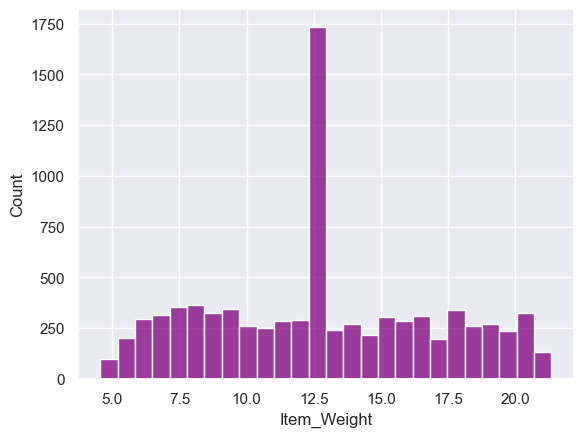

In [131]:
# Item_Weight distribution
#plt.figure(figsize=(5,5))
sns.histplot(sales_data['Item_Weight'], color='purple')
plt.show()

* Hence from the above graph we can observe that we have the item weight from 5 Kg to 20 Kg & we have maximum values around 12 Kg where the mean is 12.85 Kg

* Therefore in this 8523 products the average weight is about 12.8 Kg

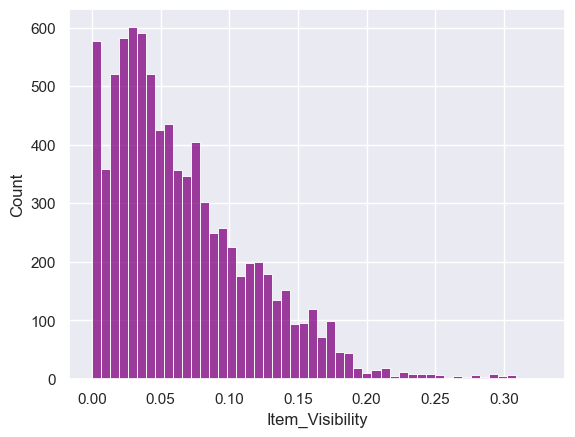

In [132]:
# Item Visibility distribution
#plt.figure(figsize=(5,5))
sns.histplot(sales_data['Item_Visibility'], color='purple')
plt.show()

* Hence from the above graph we can observe that Item_Visibility feature is positively skewed

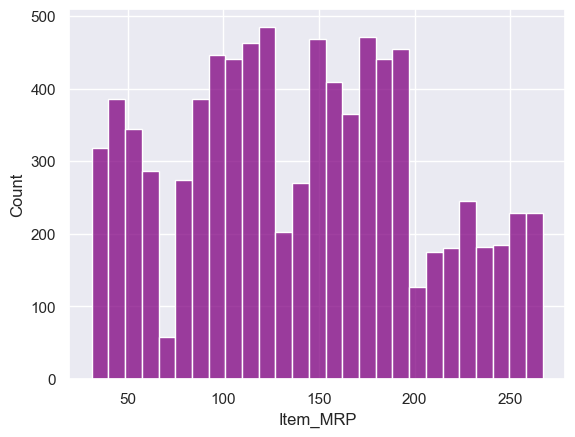

In [133]:
# Item MRP distribution
#plt.figure(figsize=(5,5))
sns.histplot(sales_data['Item_MRP'], color='purple')
plt.show()

* From the above graph, we can observe that we have good amount of products for 50 MRP,  100 MRP ,200 MRP & then we have less products 

* Hence we have more products in the range of 100 MRP - 180 MRP

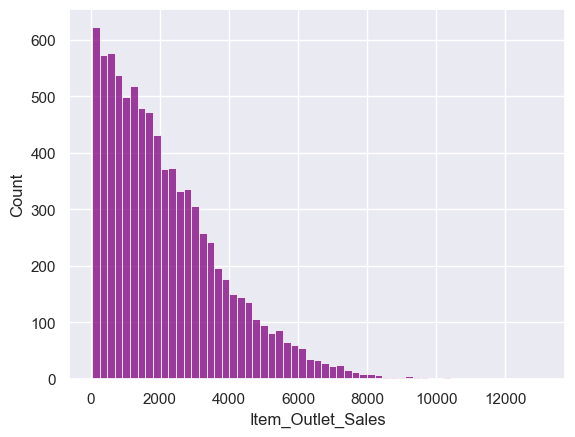

In [134]:
# Item_Outlet_Sales distribution
#plt.figure(figsize=(5,5))
sns.histplot(sales_data['Item_Outlet_Sales'], color='purple')
plt.show()

* Hence from the above graph we can observe that Item_Outlet_Sales feature is positively skewed

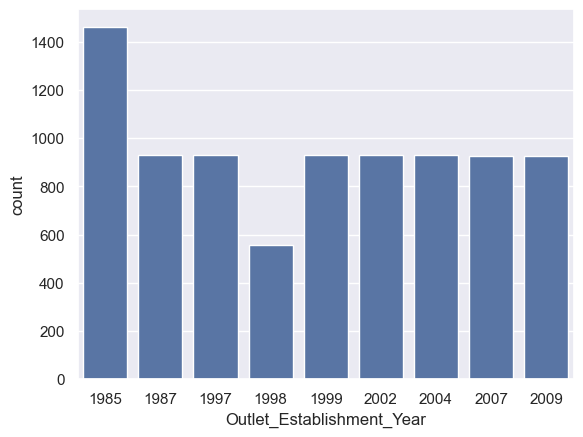

In [135]:
# Outlet_Establishment_Year column
#plt.figure(figsize=(5,5))
sns.countplot(x='Outlet_Establishment_Year', data=sales_data)
plt.show()

* Hence from the above graph we can observe that we have the outlet establishment from the year 1985, 1987 and all the way to 2009 

* Therefore these are the years on which different outlets or different stores have been established 

* We can also observe that a lots of stores are established in the year 1985 & less in the year 1998 & all the others years are almost same

**VISUALIZATION OF CATEGORICAL FEATURES**

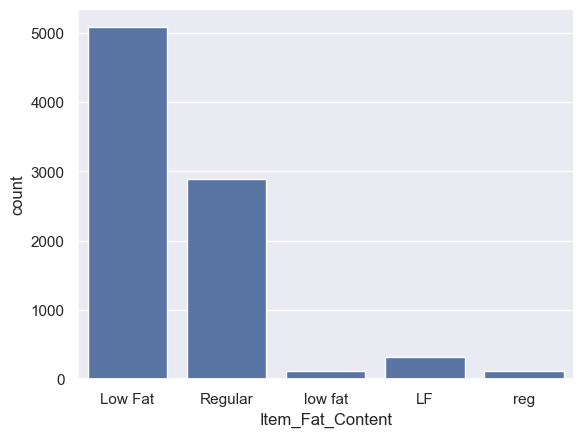

In [136]:
# Item_Fat_Content column
#plt.figure(figsize=(5,5))
sns.countplot(x='Item_Fat_Content', data=sales_data)
plt.show()

* From the above graph we can observe that the data in the Item_Fat_Content column has to be cleaned since we have columns such as Low fat,low fat & Lf which is same & must be put into a single particular label.Similarly we have Regular & reg where we need to put this into a single entity.

* Hence, we need to pre process this data so we will be dealing with this in a later point of time after the visualization of the data

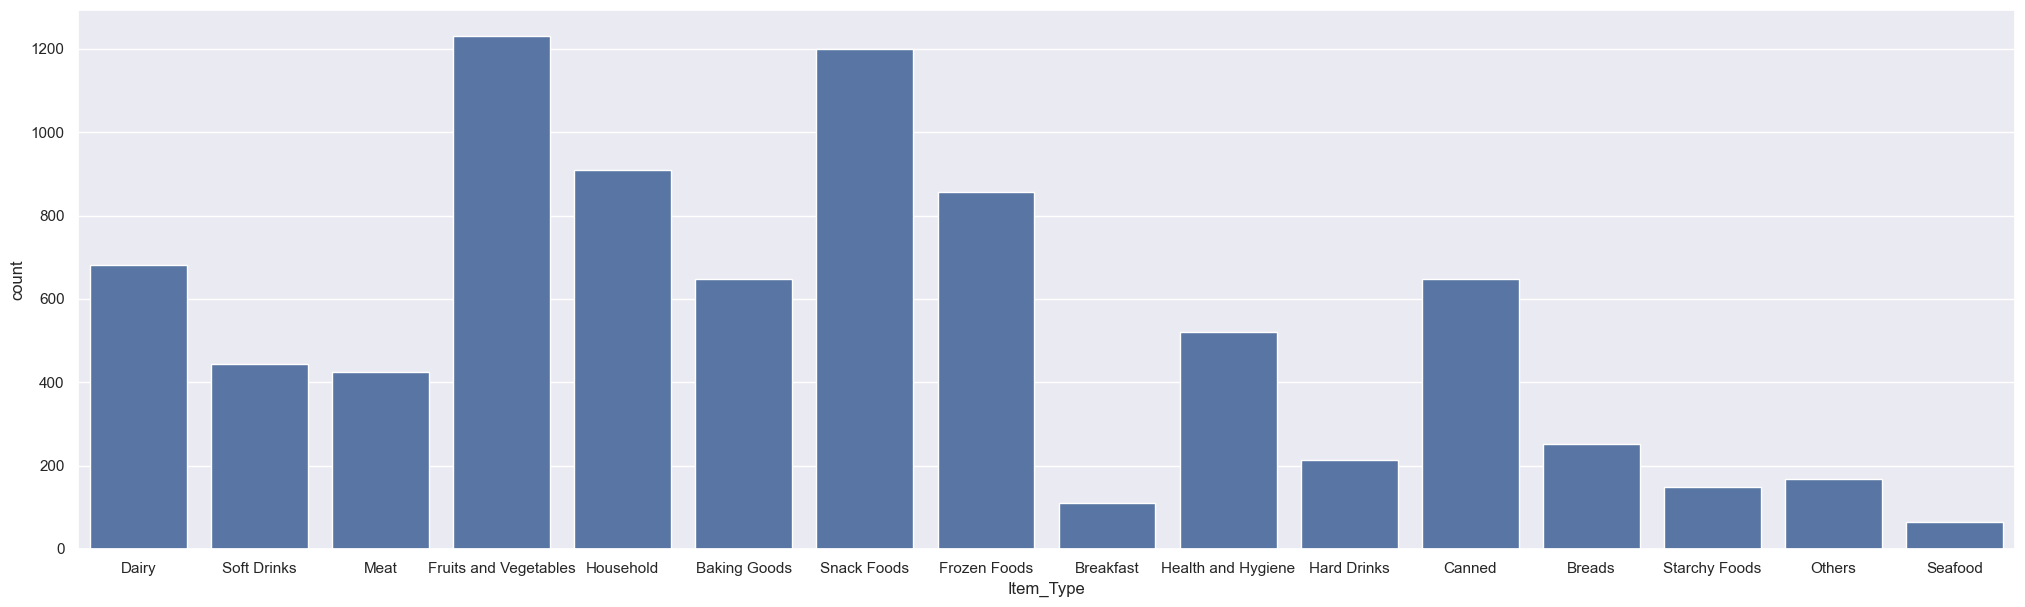

In [137]:
# Item_Type column
plt.figure(figsize=(25,7))
sns.countplot(x='Item_Type', data=sales_data)
plt.show()

* From the above graph we can observe the different items or food types we have such as dairy, soft drinks, meat, fruits & vegetables, household etc 

* Hence totally we have about 16 Item_Type values in this case where we have more values in the fruits & vegetables column and snack foods column

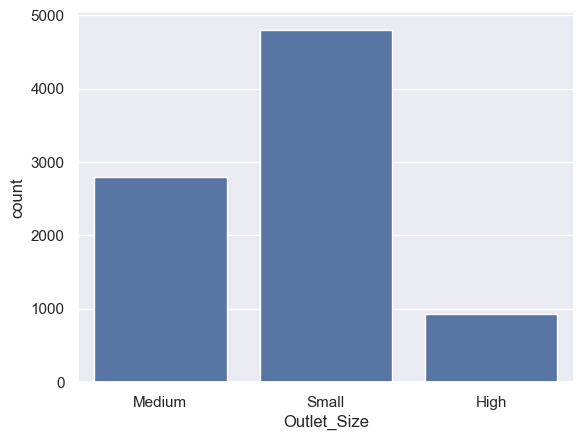

In [138]:
# Outlet_Size column
#plt.figure(figsize=(5,5))
sns.countplot(x='Outlet_Size', data=sales_data)
plt.show()

* From the above graph, we can observe that we have three outlet_Size in this case which is medium, small & high

**PREPROCESSING OF DATA**

In [139]:
sales_data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Small,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [140]:
sales_data['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

In [141]:
sales_data.replace({'Item_Fat_Content': {'low fat':'Low Fat','LF':'Low Fat', 'reg':'Regular'}}, inplace=True)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Small,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,Small,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


In [142]:
sales_data['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64

Hence, we have successfully cleaned the data in Item_Fat_Content column

**LABEL ENCODING:**
*     Label Encoding refers to the convertion of the labels into a numeric form so as to convert them into the machine-readable form. Machine learning algorithms can then decide in a better way how those labels must be operated. It is an important pre-processing step for the structured dataset in supervised learning.

*     In simple terms, taking all the categorical values & transforming them into some numerical values

In [143]:
encoder = LabelEncoder()

In [144]:
sales_data['Item_Identifier'] = encoder.fit_transform(sales_data['Item_Identifier'])

sales_data['Item_Fat_Content'] = encoder.fit_transform(sales_data['Item_Fat_Content'])

sales_data['Item_Type'] = encoder.fit_transform(sales_data['Item_Type'])

sales_data['Outlet_Identifier'] = encoder.fit_transform(sales_data['Outlet_Identifier'])

sales_data['Outlet_Size'] = encoder.fit_transform(sales_data['Outlet_Size'])

sales_data['Outlet_Location_Type'] = encoder.fit_transform(sales_data['Outlet_Location_Type'])

sales_data['Outlet_Type'] = encoder.fit_transform(sales_data['Outlet_Type'])

In [145]:
sales_data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,156,9.30,0,0.016047,4,249.8092,9,1999,1,0,1,3735.1380
1,8,5.92,1,0.019278,14,48.2692,3,2009,1,2,2,443.4228
2,662,17.50,0,0.016760,10,141.6180,9,1999,1,0,1,2097.2700
3,1121,19.20,1,0.000000,6,182.0950,0,1998,2,2,0,732.3800
4,1297,8.93,0,0.000000,9,53.8614,1,1987,0,2,1,994.7052


* Hence, we have only numerical values in our data where these categories are given some specific numerical values if it is unique

* Therefore we have successfully encoded categorical columns into numerical values which is an important data preprocessing step.

**SPLITTING FEATURES AND TARGET INTO X & Y RESPECTIVELY**

We know that the data in the "Item_Outlet_Sales" column is the target & remaining are the features

In [146]:
#Let's have all the features in X & target in Y
X = sales_data.drop(columns='Item_Outlet_Sales')
Y = sales_data['Item_Outlet_Sales']

In [147]:
# X contains features
print(X)

      Item_Identifier  Item_Weight  Item_Fat_Content  Item_Visibility  \
0                 156        9.300                 0         0.016047   
1                   8        5.920                 1         0.019278   
2                 662       17.500                 0         0.016760   
3                1121       19.200                 1         0.000000   
4                1297        8.930                 0         0.000000   
...               ...          ...               ...              ...   
8518              370        6.865                 0         0.056783   
8519              897        8.380                 1         0.046982   
8520             1357       10.600                 0         0.035186   
8521              681        7.210                 1         0.145221   
8522               50       14.800                 0         0.044878   

      Item_Type  Item_MRP  Outlet_Identifier  Outlet_Establishment_Year  \
0             4  249.8092                  9    

In [148]:
# Y contains target
print(Y)

0       3735.1380
1        443.4228
2       2097.2700
3        732.3800
4        994.7052
          ...    
8518    2778.3834
8519     549.2850
8520    1193.1136
8521    1845.5976
8522     765.6700
Name: Item_Outlet_Sales, Length: 8523, dtype: float64


**SPLITTING THE DATA INTO TRAINING DATA & TESTING DATA**

In [149]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=2)

In [150]:
print(X.shape, X_train.shape, X_test.shape)

(8523, 11) (5966, 11) (2557, 11)


We can observe that

* X contains the original data which is 8523

* X_trains contains 80% of the data which is 6818

* X_test contains 20% of the data which is 1705

**MACHINE LEARNING MODELS**

 Machine Learning Model Training and Evaluation

In [151]:
models = {
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'LightGBM': lgb.LGBMRegressor(random_state=42, verbose=-1),
    'CatBoost': CatBoostRegressor(random_state=42, verbose=0),
    'XGBoost': XGBRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, Y_train)

Model Performance Metrics Table

In [152]:
results_list = []

for name, model in models.items():
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    r2_train = metrics.r2_score(Y_train, y_train_pred)
    r2_test = metrics.r2_score(Y_test, y_test_pred)
    rmse_test = np.sqrt(metrics.mean_squared_error(Y_test, y_test_pred))
    
    results_list.append({
        'Model Name': name,
        'Training R-Squared': round(r2_train, 4),
        'Testing R-Squared': round(r2_test, 4),
        'Testing RMSE': round(rmse_test, 2)
    })

results_df = pd.DataFrame(results_list)
print(results_df.to_markdown(index=False))

| Model Name        |   Training R-Squared |   Testing R-Squared |   Testing RMSE |
|:------------------|---------------------:|--------------------:|---------------:|
| Gradient Boosting |               0.6408 |              0.599  |        1113.57 |
| LightGBM          |               0.7464 |              0.587  |        1130.06 |
| CatBoost          |               0.7834 |              0.5828 |        1135.74 |
| XGBoost           |               0.8868 |              0.5241 |        1213.06 |
| Random Forest     |               0.9379 |              0.5767 |        1144.12 |


Jupyter Notebook Model Export

In [153]:
import pickle
import lightgbm as lgb
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

models = {
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'LightGBM': lgb.LGBMRegressor(random_state=42, verbose=-1),
    'CatBoost': CatBoostRegressor(random_state=42, verbose=0),
    'XGBoost': XGBRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, Y_train)

with open('all_models.pkl', 'wb') as file:
    pickle.dump(models, file)